# 120. Chatbot - seq2seq language model

### Encoder-Decoder model

- Chatbot_data_for_Korean v1.0 dataset (https://github.com/songys/Chatbot_data) 을 이용한 Chatbot model 개발

- 챗봇 트레이닝용 문답 페어 11,876개  
- 일상다반사 - 0, 
- 이별(부정) - 1, 
- 사랑(긍정) - 2 로 레이블링  

<img src='https://github.com/ironmanciti/NLP_Lecture/raw/master/chatbot.png' width=600>

In [2]:
!pip install sentencepiece

     |████████████████████████████████| 1.2 MB 5.5 MB/s 


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sentencepiece as spm
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [4]:
LATENT_DIM = 128                # encoding space 의 latent dimensionality
EMBEDDING_DIM = 100

In [5]:
df = pd.read_csv('https://github.com/ironmanciti/NLP_Lecture/raw/master/data/ChatbotData.csv')
df.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


In [7]:
df['label'].unique()

array([0, 1, 2])

In [8]:
df.iloc[:, [0, 1]].values

array([['12시 땡!', '하루가 또 가네요.'],
       ['1지망 학교 떨어졌어', '위로해 드립니다.'],
       ['3박4일 놀러가고 싶다', '여행은 언제나 좋죠.'],
       ...,
       ['흑기사 해주는 짝남.', '설렜겠어요.'],
       ['힘든 연애 좋은 연애라는게 무슨 차이일까?', '잘 헤어질 수 있는 사이 여부인 거 같아요.'],
       ['힘들어서 결혼할까봐', '도피성 결혼은 하지 않길 바라요.']], dtype=object)

In [9]:
QnA_texts = []    
Q_texts = []
A_texts = []

for Q, A in df.iloc[:, [0, 1]].values:
    Q_texts.append(Q)
    A_texts.append(A)

QnA_texts = Q_texts + A_texts

print(len(QnA_texts), len(Q_texts), len(A_texts))
print("Question :")
print(Q_texts[:5])
print("Answer :")
print(A_texts[:5])

23646 11823 11823
Question :
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네']
Answer :
['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.', '여행은 언제나 좋죠.', '눈살이 찌푸려지죠.']


In [10]:
with open('chatbot_qna.txt', 'w', encoding='utf-8') as f:
    for line in QnA_texts:
        f.write(line + '\n')

In [11]:
input_file = 'chatbot_qna.txt'
pad_id=0  #<pad> token을 0으로 설정
vocab_size = 5000 # vocab 사이즈
prefix = 'chatbot_qna' # 저장될 tokenizer 모델에 붙는 이름
bos_id=1 #<s> token을 1으로 설정
eos_id=2 #</s> token을 2으로 설정
unk_id=3 #<unknown> token을 3으로 설정

cmd = f'--input={input_file} \
--pad_id={pad_id} \
--bos_id={bos_id} \
--eos_id={eos_id} \
--unk_id={unk_id} \
--model_prefix={prefix} \
--vocab_size={vocab_size}'

spm.SentencePieceTrainer.Train(cmd)

In [59]:
sp = spm.SentencePieceProcessor()
sp.Load(f'{prefix}.model')

True

In [60]:
sp.DecodeIds([170, 367, 10, 129, 16, 4])

'저도 도움이 될 거예요.'

In [14]:
sp.SetEncodeExtraOptions('bos:')
pieces = sp.encode_as_pieces('아버지가 방에 들어가신다')
print(pieces)
ids = sp.encode_as_ids('아버지가 방에 들어가신다')
print(ids)
print(sp.DecodePieces(pieces))
print(sp.DecodeIds(ids))

['<s>', '▁아', '버', '지', '가', '▁방', '에', '▁들어가', '신', '다']
[1, 222, 2140, 15, 7, 1435, 29, 1687, 468, 57]
아버지가 방에 들어가신다
아버지가 방에 들어가신다


'저도 도움이 될 거예요.'

In [15]:
sp.SetEncodeExtraOptions(':eos')
pieces = sp.encode_as_pieces('아버지가 방에 들어가신다')
print(pieces)
ids = sp.encode_as_ids('아버지가 방에 들어가신다')
print(ids)
print(sp.DecodePieces(pieces))
print(sp.DecodeIds(ids))

['▁아', '버', '지', '가', '▁방', '에', '▁들어가', '신', '다', '</s>']
[222, 2140, 15, 7, 1435, 29, 1687, 468, 57, 2]
아버지가 방에 들어가신다
아버지가 방에 들어가신다


In [16]:
sp.Load(f'{prefix}.model')
question_sequences = [sp.encode_as_ids(sent) for sent in Q_texts]

print(question_sequences[:5])

[[4307, 299, 5, 4792, 72, 2], [290, 15, 1402, 680, 1758, 2], [323, 1297, 2851, 79, 3000, 99, 2], [323, 1297, 2851, 79, 666, 3000, 99, 2], [5, 4551, 4551, 3, 1411, 66, 2]]


In [17]:
sp.SetEncodeExtraOptions('bos:')
answer_sequences_inputs = [sp.encode_as_ids(sent) for sent in A_texts]

print(answer_sequences_inputs[:5])

[[1, 282, 7, 115, 78, 23, 4], [1, 1479, 5, 3791, 4], [1, 293, 14, 386, 39, 204, 4], [1, 293, 14, 386, 39, 204, 4], [1, 205, 996, 10, 2483, 3138, 161, 15, 40, 4]]


In [18]:
sp.SetEncodeExtraOptions(':eos')
answer_sequences_targets = [sp.encode_as_ids(sent) for sent in A_texts]

print(answer_sequences_targets[:5])

[[282, 7, 115, 78, 23, 4, 2], [1479, 5, 3791, 4, 2], [293, 14, 386, 39, 204, 4, 2], [293, 14, 386, 39, 204, 4, 2], [205, 996, 10, 2483, 3138, 161, 15, 40, 4, 2]]


Target Text 의 최대 길이 : 56
Target Text 의 최대 길이 : 76


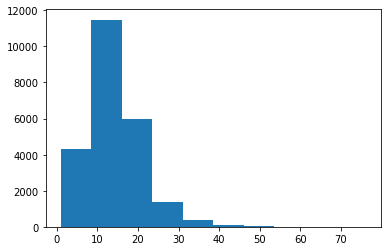

In [19]:
max_len_question = max(len(s) for s in Q_texts)
print("Target Text 의 최대 길이 :", max_len_question)

max_len_answer = max(len(s) for s in A_texts)
print("Target Text 의 최대 길이 :", max_len_answer)

plt.hist([len(s) for s in QnA_texts]);

In [20]:
MAX_LEN = 30

## sequence padding


#### 주의 사항
- encoder 는 thought vector 생성 목적이므로 default (pre) 로 padding

- decoder 는 teacher forcing 을 해야하므로 post 로 padding

In [21]:
encoder_inputs = pad_sequences(question_sequences, maxlen=MAX_LEN)
print("encoder input shape :", encoder_inputs.shape)
print("encoder_inputs[0] : ", encoder_inputs[1500])

decoder_inputs = pad_sequences(answer_sequences_inputs, maxlen=MAX_LEN, padding="post")
print("\ndecoder input shape :", decoder_inputs.shape)
print("decoder_inputs[0] : ", decoder_inputs[1500])

decoder_targets = pad_sequences(answer_sequences_targets, maxlen=MAX_LEN, padding="post")
print("\nencoder target shape :", decoder_targets.shape)
print("encoder_targets[0] : ", decoder_targets[1500])

encoder input shape : (11823, 30)
encoder_inputs[0] :  [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0  159 1534  309
 2428    2]

decoder input shape : (11823, 30)
decoder_inputs[0] :  [   1 1160   34 3050   44    4    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]

encoder target shape : (11823, 30)
encoder_targets[0] :  [1160   34 3050   44    4    2    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


## Build the model

- encoder 와 decoder 의 embedding, lstm 및 dense layer 를 training 할 목적의 model 작성  

- encoder 는 decoder 에 states [h, c] 만 전달

- prediction 을 위한 inference model 은 training model 에서 만들어진 layer 들의 weight 를 이용하여 별도 작성  

### Training : Encoder + Teacher Forcing model

In [27]:
#### Encoder -----------------------------------------------------------
encoder_inputs_ = Input(shape=(MAX_LEN,), name='Encoder_Input')
# encoder 의 embedding layer
embedding_encoder = Embedding(vocab_size + 1, EMBEDDING_DIM)

x = embedding_encoder(encoder_inputs_)

encoder_outputs, h, c = LSTM(LATENT_DIM, return_state=True)(x)
# encoder 는 hidden state and cell state 만 decoder 로 전달 
encoder_states = [h, c]  # --> thought vector

#### Decoder ------------------------------------------------------------
# decoder 는 [h, c] 를 initial state 로 사용
decoder_inputs_ = Input(shape=(MAX_LEN,), name='Decoder_Input')

# decoder 의 embedding layer
embedding_decoder = Embedding(vocab_size + 1, EMBEDDING_DIM)
x = embedding_decoder(decoder_inputs_)
decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(x, initial_state=encoder_states)

# final dense layer
decoder_dense = Dense(vocab_size, activation='softmax', name='Decoder_Output')
decoder_outputs = decoder_dense(decoder_outputs)

# Create the model object
model = Model([encoder_inputs_, decoder_inputs_], decoder_outputs)

In [28]:
#Compile the model and train it
model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Encoder_Input (InputLayer)      [(None, 30)]         0                                            
__________________________________________________________________________________________________
Decoder_Input (InputLayer)      [(None, 30)]         0                                            
__________________________________________________________________________________________________
embedding_3 (Embedding)         (None, 30, 100)      500100      Encoder_Input[0][0]              
__________________________________________________________________________________________________
embedding_4 (Embedding)         (None, 30, 100)      500100      Decoder_Input[0][0]              
____________________________________________________________________________________________

### Train the model

In [29]:
EPOCHS = 40
BATCH_SIZE = 64
history = model.fit([encoder_inputs, decoder_inputs], decoder_targets, batch_size=BATCH_SIZE, epochs=EPOCHS, 
                   validation_split=0.2)

Epoch 1/40
148/148 [==============================] - 9s 24ms/step - loss: 2.0768 - accuracy: 0.7513 - val_loss: 1.7963 - val_accuracy: 0.7571
Epoch 2/40
148/148 [==============================] - 3s 20ms/step - loss: 1.3778 - accuracy: 0.8029 - val_loss: 1.6774 - val_accuracy: 0.7653
Epoch 3/40
148/148 [==============================] - 3s 20ms/step - loss: 1.2987 - accuracy: 0.8084 - val_loss: 1.6476 - val_accuracy: 0.7699
Epoch 4/40
148/148 [==============================] - 3s 20ms/step - loss: 1.2606 - accuracy: 0.8114 - val_loss: 1.6348 - val_accuracy: 0.7726
Epoch 5/40
148/148 [==============================] - 3s 20ms/step - loss: 1.2315 - accuracy: 0.8142 - val_loss: 1.6166 - val_accuracy: 0.7746
Epoch 6/40
148/148 [==============================] - 3s 20ms/step - loss: 1.2026 - accuracy: 0.8173 - val_loss: 1.5948 - val_accuracy: 0.7775
Epoch 7/40
148/148 [==============================] - 3s 20ms/step - loss: 1.2197 - accuracy: 0.8154 - val_loss: 1.5832 - val_accuracy: 0.7802

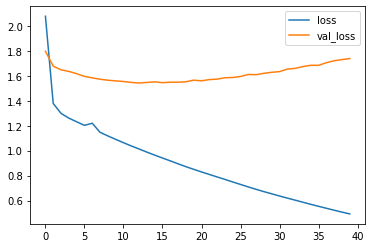

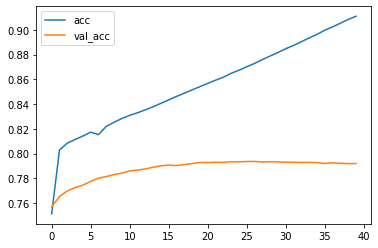

In [30]:
# plot some data
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

# accuracies
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [31]:
# save model
model.save('s2s.h5')

### Make Predictions - Inference phase

- prediction 을 위한 별도의 encoder model 
- encoder 의 states 를 initial state 로 받는 decoder model 작성  

- encoder 는 training 단계와 동일하게 input_text 를 입력으로 받고 encoder_states 를 출력으로 하므로 이전에 define 한 encoder_input_ 과 encoder_states 변수 재사용

In [32]:
# Encoder model for inference
encoder_model = Model(encoder_inputs_, encoder_states)

# Decoder
decoder_state_input_h = Input(shape=(LATENT_DIM,), name='Decoder_hidden_h')
decoder_state_input_c = Input(shape=(LATENT_DIM,), name='Decoder_hidden_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='Decoder_input')
x = embedding_decoder(decoder_inputs_single)

# output, hidden states 를 저장
decoder_outputs, h, c = decoder_lstm(x, initial_state=decoder_states_inputs)
decoder_states = [h, c]

decoder_outputs = decoder_dense(decoder_outputs)  

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,    #decoder_model.predict([target_seq] + states_value)
    [decoder_outputs] + decoder_states
)

encoder_model.summary()

decoder_model.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Encoder_Input (InputLayer)   [(None, 30)]              0         
_________________________________________________________________
embedding_3 (Embedding)      (None, 30, 100)           500100    
_________________________________________________________________
lstm_3 (LSTM)                [(None, 128), (None, 128) 117248    
Total params: 617,348
Trainable params: 617,348
Non-trainable params: 0
_________________________________________________________________
Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Decoder_input (InputLayer)      [(None, 1)]          0                                            
_____________________________________________________________________

### 다음의 inference module 작성
- question 을 encoder 에 입력하여 thought vector 반환
- start token 설정 
- 가장 확률 높은 next word 선택
- end token 생성 될 때까지 반복
- predict 결과가 sequence 로 반환되므로 index 를 word 로 변환

In [73]:
def decode_sequence(input_seq):
   # 입력된 질문을 encoder 에 입력하여 state vector 생성
    states_value = encoder_model.predict(input_seq)
    # size 1 짜리 빈 target sequence 생성
    target_seq = np.zeros((1, 1))
    # target sequence 의 첫번째 character 를 <s> 로 assign - 1
    target_seq[0, 0] = 1
    eos = 2  #</s>

    # 답변 생성 시작
    output_ids = []
    for _ in range(max_len_answer):
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

       # argmax 로 가장 확률 높은 단어 선택 --> greedy selection
        idx = np.argmax(output_tokens[0, 0, :])

        if eos == idx:  # End sentence of EOS
            break

        if idx > 0:      # idx 0 은 zero padding 이므로 skip
            output_ids.append(int(idx))

        # 생성된 word 를 decoder 의 다음 input 으로 사용
        target_seq[0, 0] = idx
        # Update states
        states_value = [h, c]

    return output_ids

- sample Q & A test

In [84]:
sp.Load(f'{prefix}.model')

for _ in range(5):
    i = np.random.choice(len(Q_texts))
    input_seq = encoder_inputs[i:i+1]
    response = decode_sequence(input_seq)
    print('-')
    print('질문 :', Q_texts[i])
    print('답변 :', sp.DecodeIds(response))

-
질문 : 장수커플이야
답변 : 언젠간 올 순간이었을 거예요.
-
질문 : 공허함이 크네
답변 : 제가 채워줄게요.
-
질문 : 남자친구가 사업한대
답변 : 나중에 후회할 거예요.
-
질문 : 짝녀가 내 친구를 좋아해.
답변 : 그게 힘들 때가 있어요.
-
질문 : 남자가 돈을 더 써야하는게 일반적이야?
답변 : 원하는 게 가장 나과 변화도 돼요.


In [85]:
txt = "정말 미워"
input_sequence = sp.encode_as_ids(txt)
encoder_input = pad_sequences([input_sequence], maxlen=MAX_LEN)

response = decode_sequence(encoder_input)
print('-')
print('질문', txt)
print('답변:', sp.DecodeIds(response))

-
질문 정말 미워
답변: 항상 조심하세요.


In [87]:
print("챗봇 대화 시작 .....")

while True:
    txt = input("질문 :")
    if txt.lower() == "quit":
        break
    
    input_sequence = sp.encode_as_ids(txt)
    encoder_input = pad_sequences([input_sequence], maxlen=MAX_LEN)

    answer = decode_sequence(encoder_input)

    print("답변 :", sp.DecodeIds(answer))

챗봇 대화 시작 .....
질문 :12시 땡
답변 : 잘 지내고 있을 거예요.
질문 :1지망 학교 떨어졌어
답변 : 푹 쉬세요.
질문 :sd카드 망가졌어
답변 : 운동을 해보세요.
질문 :여행은 언제나 좋죠
답변 : 좋은 일이 있었나봐요.
질문 :quit
